<a href="https://colab.research.google.com/github/mikhail-mat/rl-intro-sutton-barto/blob/main/dynamic_programming_gambler_mdp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Solving an MDP with Dynamic Programming**

### **Setup**

This MDP models a scenario, where the state of the environment can be fully described by how many coins you currently have and how many remaining plays are left. The two actions that the agent can choose to take are either to gamble or not to gamble.

The game starts with a certain number of coins ```starting_capital``` and with T plays (or timesteps) remaining. In each of these T plays you can choose to gamble, which will result in a win with a fixed probability of ```win_prob``` and a loss with probability of one minus that, ```lose_prob```. Winning awards 100 coins, and losing costs 100 coins. You can also choose not to gamble, which results in losing no coins and only a reduction in the number of remaining plays. This carries on until you reach a terminal state with either no plays remaining or 0 coins. This is described by the state-transition function ```transitions(state, action)```.

The goal of the game is to have as much money as possible by the time you run out of plays. At the same time, the agent is trying to get to a certain amount, which if reaches produces a bonus reward. This is characterised by the reward function ```reward(state)```.

---

### **Approach**

The approach used to solve this MDP is a one sweep through the state-space by using value iteration, a dynamic programming algorithm. It is possible to apply DP as the dynamics of the environment are fully known. The reason why one sweep is sufficient to find the optimal value function is because all episodes terminate. Therefore, by starting with the values of the states at the end of the episode, which can be found just by getting the immediate reward, all other values must converge to the true values if you traverse the states in the order such that a state's successors are always already computed when you reach it.

---

### **Results**

The optimal policy found by the algorithm can be seen at the bottom of this colab, showing that the agent either prioritises gambling or it's a tie when the current number of coins is close to the goal amount which gives you the bonus, while being further away from the goal amount means you shouldn't gamble to keep what you have.

In [141]:
# p(s',r|s,a) - environment dynamics
# p(s'|s,a) - state transition probabilities
# r(s',s,a) - rewards

In [142]:
# assume you can have T plays

starting_capital = 1000
T = 25

states = []

for remaining_plays in range(T+1):
  used_up_plays = T - remaining_plays

  for plays in range(used_up_plays+1):
    win_coins = starting_capital + 100*plays
    lose_coins = starting_capital - 100*plays

    states.append((win_coins, remaining_plays))
    if win_coins != lose_coins and lose_coins >= 0:
        states.append((lose_coins, remaining_plays))

In [143]:
states

[(1000, 0),
 (1100, 0),
 (900, 0),
 (1200, 0),
 (800, 0),
 (1300, 0),
 (700, 0),
 (1400, 0),
 (600, 0),
 (1500, 0),
 (500, 0),
 (1600, 0),
 (400, 0),
 (1700, 0),
 (300, 0),
 (1800, 0),
 (200, 0),
 (1900, 0),
 (100, 0),
 (2000, 0),
 (0, 0),
 (2100, 0),
 (2200, 0),
 (2300, 0),
 (2400, 0),
 (2500, 0),
 (2600, 0),
 (2700, 0),
 (2800, 0),
 (2900, 0),
 (3000, 0),
 (3100, 0),
 (3200, 0),
 (3300, 0),
 (3400, 0),
 (3500, 0),
 (1000, 1),
 (1100, 1),
 (900, 1),
 (1200, 1),
 (800, 1),
 (1300, 1),
 (700, 1),
 (1400, 1),
 (600, 1),
 (1500, 1),
 (500, 1),
 (1600, 1),
 (400, 1),
 (1700, 1),
 (300, 1),
 (1800, 1),
 (200, 1),
 (1900, 1),
 (100, 1),
 (2000, 1),
 (0, 1),
 (2100, 1),
 (2200, 1),
 (2300, 1),
 (2400, 1),
 (2500, 1),
 (2600, 1),
 (2700, 1),
 (2800, 1),
 (2900, 1),
 (3000, 1),
 (3100, 1),
 (3200, 1),
 (3300, 1),
 (3400, 1),
 (1000, 2),
 (1100, 2),
 (900, 2),
 (1200, 2),
 (800, 2),
 (1300, 2),
 (700, 2),
 (1400, 2),
 (600, 2),
 (1500, 2),
 (500, 2),
 (1600, 2),
 (400, 2),
 (1700, 2),
 (300, 2),

In [144]:
actions = ['gamble', 'not gamble']

In [145]:
def is_terminal(state):
  if state[1] == 0 or state[0] < 100:
    return True
  return False

In [146]:
max_coins = starting_capital + 100*T

def transitions(state, action):
  if is_terminal(state):
    return []

  if action == 'gamble':
    win_state = (state[0]+100, state[1]-1)
    #win_prob = state[0] / max_coins
    win_prob = 0.4

    lose_state = (state[0]-100, state[1]-1)
    #lose_prob = 1 - (state[0] / max_coins)
    lose_prob = 0.6

    return [(win_state, win_prob), (lose_state, lose_prob)]

  elif action == 'not gamble':
    return [((state[0], state[1]-1), 1.0)]

In [147]:
goal = 1500

def reward(state):
  if is_terminal(state):
    bonus = 0
    if state[0] >= goal:
      bonus = 500
    return state[0] + bonus
  return 0

### initialise values of all states arbitrarily, except for terminal states which have the value of their reward

In [148]:
V = dict()
for state in states:
    V[state] = 0

In [149]:
V[(1000, 0)]

0

In [150]:
for state in states:
  if is_terminal(state):
    continue

  max_return = float('-inf')

  for action in actions:
    expected_return = 0
    for next_state, prob in transitions(state, action):
      expected_return += (reward(next_state) + V[next_state]) * prob
    if expected_return > max_return:
      max_return = expected_return

  V[state] = max_return

In [151]:
pi = dict()

for state in states:
  if is_terminal(state):
    pi[state] = 'terminal'
    continue

  max_return = float('-inf')
  max_action = None

  for action in actions:
    expected_return = 0
    for next_state, prob in transitions(state, action):
      expected_return += (reward(next_state) + V[next_state]) * prob

    if expected_return > max_return:
      max_return = expected_return
      max_action = action
    elif expected_return == max_return:
      max_action = 'tie'

  pi[state] = max_action

In [152]:
for state, optimal_action in pi.items():
  print(f'state: {state}  ---  action: {optimal_action}')

state: (1000, 0)  ---  action: terminal
state: (1100, 0)  ---  action: terminal
state: (900, 0)  ---  action: terminal
state: (1200, 0)  ---  action: terminal
state: (800, 0)  ---  action: terminal
state: (1300, 0)  ---  action: terminal
state: (700, 0)  ---  action: terminal
state: (1400, 0)  ---  action: terminal
state: (600, 0)  ---  action: terminal
state: (1500, 0)  ---  action: terminal
state: (500, 0)  ---  action: terminal
state: (1600, 0)  ---  action: terminal
state: (400, 0)  ---  action: terminal
state: (1700, 0)  ---  action: terminal
state: (300, 0)  ---  action: terminal
state: (1800, 0)  ---  action: terminal
state: (200, 0)  ---  action: terminal
state: (1900, 0)  ---  action: terminal
state: (100, 0)  ---  action: terminal
state: (2000, 0)  ---  action: terminal
state: (0, 0)  ---  action: terminal
state: (2100, 0)  ---  action: terminal
state: (2200, 0)  ---  action: terminal
state: (2300, 0)  ---  action: terminal
state: (2400, 0)  ---  action: terminal
state: (2500

In [153]:
# a - action
# ns - next_state
# p - probability
def action_values(state):
    return {a: sum((reward(ns) + V[ns]) * p for ns, p in transitions(state, a))
            for a in actions}

# values can really be identical but differ slightly due to computation
TOL = 1e-9

# qs - action-values of states
def classify(state):
    if is_terminal(state):
        return 'terminal'
    qs = action_values(state)
    best = max(qs.values())
    winners = [a for a, v in qs.items() if abs(v - best) < TOL]
    return 'tie' if len(winners) > 1 else winners[0]

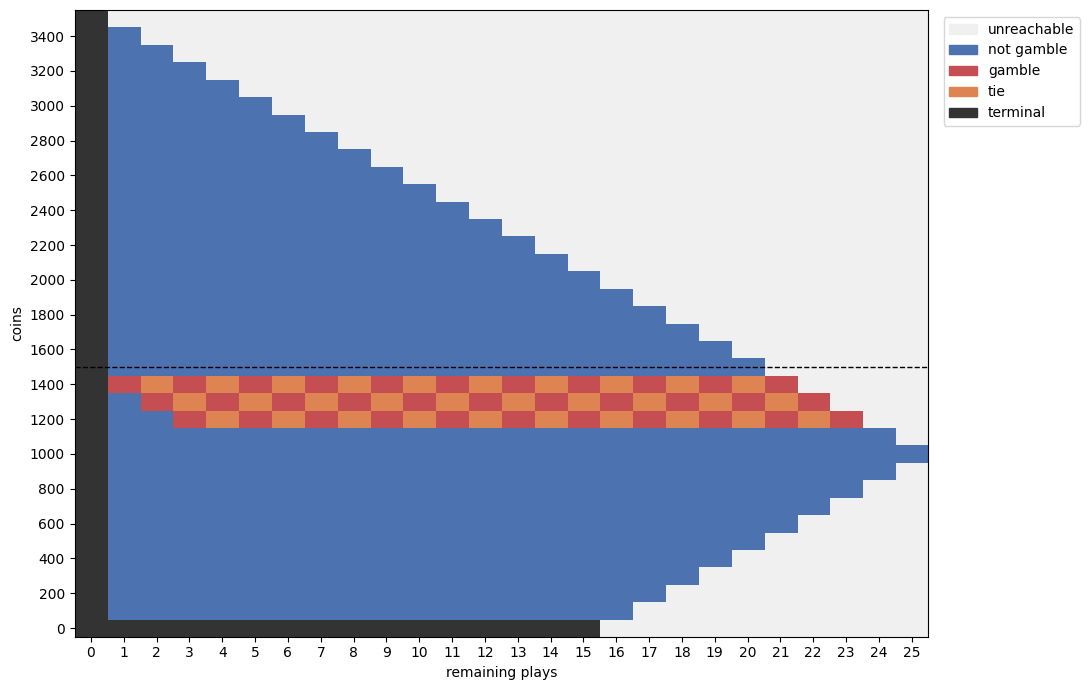

In [154]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

coin_vals = sorted({s[0] for s in states})
play_vals = sorted({s[1] for s in states})
ci = {c: i for i, c in enumerate(coin_vals)}
pi_ = {p: j for j, p in enumerate(play_vals)}

codes = {'unreachable': 0, 'not gamble': 1, 'gamble': 2, 'tie': 3, 'terminal': 4}
colors = ['#f0f0f0', '#4C72B0', '#C44E52', '#DD8452', '#333333']

grid = np.zeros((len(coin_vals), len(play_vals)))
for s in states:
    grid[ci[s[0]], pi_[s[1]]] = codes[classify(s)]

fig, ax = plt.subplots(figsize=(11, 7))
ax.imshow(grid, cmap=ListedColormap(colors), vmin=0, vmax=4,
          origin='lower', aspect='auto')
ax.axhline(ci[goal], color='k', ls='--', lw=1)

ax.set_xticks(range(len(play_vals)))
ax.set_xticklabels(play_vals)
ax.set_yticks(range(len(coin_vals))[::2])
ax.set_yticklabels(coin_vals[::2])
ax.set_xlabel('remaining plays')
ax.set_ylabel('coins')
ax.legend(handles=[Patch(color=c, label=l) for l, c in zip(codes, colors)],
          bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()